# Yield Curve Monitor
### Live US Treasury Yield Curve Analysis

**Author:** Ryan John  
**Purpose:** Monitor the US Treasury yield curve, track key spreads, and flag inversions  
**Data Source:** Federal Reserve Economic Data (FRED)  

---

This monitor tracks:
- **Live yield curve** — current Treasury yields across all maturities
- **Key spreads** — 2s10s, 5s30s, 2s5s10s butterfly
- **Historical comparison** — current curve vs 1 month, 3 months, 1 year ago
- **Inversion detection** — automatic flag when curve inverts
- **Curve shape classification** — normal, flat, inverted, humped

---
## 1. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# For pulling live data from FRED
try:
    import pandas_datareader as pdr
    LIVE_DATA = True
    print('pandas_datareader loaded — live FRED data available')
except ImportError:
    LIVE_DATA = False
    print('pandas_datareader not installed — using sample data')
    print('To install: run  !pip install pandas_datareader  in a new cell')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':  '#0a0e14',
    'axes.facecolor':    '#0f1520',
    'axes.edgecolor':    '#1e2d42',
    'axes.labelcolor':   '#c8d8e8',
    'xtick.color':       '#4a6480',
    'ytick.color':       '#4a6480',
    'text.color':        '#c8d8e8',
    'grid.color':        '#1e2d42',
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
    'font.size':         10,
})

print('Setup complete')

pandas_datareader not installed — using sample data
To install: run  !pip install pandas_datareader  in a new cell
Setup complete


---
## 2. Pull Treasury Yield Data

Data comes from FRED — the Federal Reserve's free data platform.  
If you don't have pandas_datareader installed, sample data is used instead.

In [9]:
# Treasury yield FRED tickers
TICKERS = {
    '1M':  'DGS1MO',
    '3M':  'DGS3MO',
    '6M':  'DGS6MO',
    '1Y':  'DGS1',
    '2Y':  'DGS2',
    '3Y':  'DGS3',
    '5Y':  'DGS5',
    '7Y':  'DGS7',
    '10Y': 'DGS10',
    '20Y': 'DGS20',
    '30Y': 'DGS30',
}

# Maturities in years for plotting
MATURITIES = {
    '1M': 1/12, '3M': 3/12, '6M': 6/12,
    '1Y': 1,    '2Y': 2,    '3Y': 3,
    '5Y': 5,    '7Y': 7,    '10Y': 10,
    '20Y': 20,  '30Y': 30,
}

if LIVE_DATA:
    print('Pulling live Treasury yields from FRED...')
    try:
        # Pull 2 years of history
        raw = pd.concat([
            pdr.get_data_fred(ticker, start='2023-01-01').rename(columns={ticker: label})
            for label, ticker in TICKERS.items()
        ], axis=1)
        raw = raw.dropna(how='all')
        print(f'Data pulled: {len(raw)} trading days from {raw.index[0].date()} to {raw.index[-1].date()}')
    except Exception as e:
        print(f'FRED pull failed: {e}')
        LIVE_DATA = False

if not LIVE_DATA:
    print('Using sample yield curve data...')
    # Realistic sample data representing a typical yield curve environment
    dates = pd.date_range('2023-01-01', '2026-03-28', freq='B')
    np.random.seed(42)
    
    # Base yields with realistic curve shape
    base = {'1M':5.30,'3M':5.28,'6M':5.20,'1Y':5.00,'2Y':4.80,
            '3Y':4.65,'5Y':4.45,'7Y':4.38,'10Y':4.30,'20Y':4.45,'30Y':4.50}
    
    data = {}
    for label, y in base.items():
        noise  = np.random.normal(0, 0.02, len(dates)).cumsum() * 0.1
        data[label] = np.clip(y + noise, 0.5, 8.0)
    
    raw = pd.DataFrame(data, index=dates)
    print(f'Sample data created: {len(raw)} days')

print()
print('Latest yields:')
latest = raw.iloc[-1].dropna()
for label, yield_val in latest.items():
    print(f'  {label:>4}: {yield_val:.3f}%')

Using sample yield curve data...
Sample data created: 845 days

Latest yields:
    1M: 5.295%
    3M: 5.443%
    6M: 5.218%
    1Y: 4.983%
    2Y: 4.742%
    3Y: 4.614%
    5Y: 4.326%
    7Y: 4.359%
   10Y: 4.275%
   20Y: 4.499%
   30Y: 4.530%


---
## 3. Key Spread Calculations

Spreads are the difference between two points on the yield curve.  
They tell you about the curve's shape and what the market is pricing for growth and inflation.

In [10]:
def calculate_spreads(df):
    """
    Calculate key yield curve spreads.
    
    2s10s  — most watched spread globally
             Positive = normal curve
             Negative = inverted curve (recession signal)
    
    5s30s  — long end slope
             Shows long term inflation and growth expectations
    
    2s5s10s butterfly — curve curvature
             Measures if belly is cheap or rich vs wings
             Positive = belly rich (hump shape)
             Negative = belly cheap (inverse hump)
    """
    spreads = pd.DataFrame(index=df.index)
    
    # Key spreads in basis points
    if '2Y' in df.columns and '10Y' in df.columns:
        spreads['2s10s']     = (df['10Y'] - df['2Y']) * 100    # bps
    if '5Y' in df.columns and '30Y' in df.columns:
        spreads['5s30s']     = (df['30Y'] - df['5Y']) * 100
    if '2Y' in df.columns and '5Y' in df.columns:
        spreads['2s5s']      = (df['5Y']  - df['2Y']) * 100
    if '3M' in df.columns and '10Y' in df.columns:
        spreads['3m10y']     = (df['10Y'] - df['3M']) * 100
    if '2Y' in df.columns and '5Y' in df.columns and '10Y' in df.columns:
        spreads['butterfly'] = (df['5Y'] - (df['2Y'] + df['10Y']) / 2) * 100
    
    return spreads.dropna(how='all')


spreads = calculate_spreads(raw)
current_spreads = spreads.iloc[-1]

print('KEY YIELD CURVE SPREADS')
print('=' * 55)
print(f'{"Spread":<12} {"Current":>10} {"1M Ago":>10} {"3M Ago":>10}')
print('-' * 55)

for spread_name in spreads.columns:
    current = spreads[spread_name].iloc[-1]
    m1_ago  = spreads[spread_name].iloc[-22]  if len(spreads) > 22  else np.nan
    m3_ago  = spreads[spread_name].iloc[-66]  if len(spreads) > 66  else np.nan
    
    flag = ''
    if spread_name == '2s10s' and current < 0:
        flag = ' ⚠ INVERTED'
    elif spread_name == '2s10s' and current > 0:
        flag = ' ✓ NORMAL'
    
    print(f'{spread_name:<12} {current:>+9.1f}bps {m1_ago:>+9.1f}bps {m3_ago:>+9.1f}bps{flag}')

print('=' * 55)
print()
print('Interpretation:')
print('  2s10s > 0  → Normal curve  → Economy expanding')
print('  2s10s < 0  → Inverted curve → Recession signal')
print('  5s30s      → Long end steepness → Inflation expectations')
print('  Butterfly  → Curve curvature → Relative value signal')

KEY YIELD CURVE SPREADS
Spread          Current     1M Ago     3M Ago
-------------------------------------------------------
2s10s            -46.6bps     -47.8bps     -50.3bps ⚠ INVERTED
5s30s            +20.4bps     +20.6bps     +17.2bps
2s5s             -41.6bps     -42.9bps     -41.1bps
3m10y           -116.8bps    -115.8bps    -113.9bps
butterfly        -18.3bps     -19.0bps     -16.0bps

Interpretation:
  2s10s > 0  → Normal curve  → Economy expanding
  2s10s < 0  → Inverted curve → Recession signal
  5s30s      → Long end steepness → Inflation expectations
  Butterfly  → Curve curvature → Relative value signal


---
## 4. Curve Shape Classification

Automatically identifies the current shape of the yield curve.

In [11]:
def classify_curve(yields):
    """
    Classify yield curve shape based on current yields.
    
    Normal   — short rates < long rates (upward sloping)
    Inverted — short rates > long rates (downward sloping)
    Flat     — short rates ≈ long rates
    Humped   — middle rates highest (belly rich)
    """
    if '2Y' not in yields or '10Y' not in yields or '30Y' not in yields:
        return 'Insufficient data'
    
    spread_2s10s  = yields['10Y'] - yields['2Y']
    spread_10s30s = yields['30Y'] - yields['10Y']
    
    if abs(spread_2s10s) < 0.10:      # within 10bps
        return 'FLAT'
    elif spread_2s10s < -0.10:
        return 'INVERTED'
    elif spread_2s10s > 0.10 and spread_10s30s < -0.10:
        return 'HUMPED'
    else:
        return 'NORMAL'


def inversion_check(yields):
    """
    Check all key curve segments for inversion.
    Returns list of inverted segments.
    """
    inversions = []
    pairs = [
        ('3M', '2Y',  '3m2y'),
        ('2Y', '5Y',  '2s5s'),
        ('2Y', '10Y', '2s10s'),
        ('5Y', '30Y', '5s30s'),
        ('3M', '10Y', '3m10y'),
    ]
    for short, long, name in pairs:
        if short in yields and long in yields:
            if yields[long] < yields[short]:
                inversions.append(name)
    return inversions


latest_yields = raw.iloc[-1].dropna()
curve_shape   = classify_curve(latest_yields)
inversions    = inversion_check(latest_yields)

print('CURVE SHAPE ANALYSIS')
print('=' * 45)
print(f'  Current Shape:     {curve_shape}')
print(f'  Inverted Segments: {len(inversions)}')

if inversions:
    print(f'  Inverted Pairs:    {", ".join(inversions)}')
    print()
    print('  ⚠  INVERSION DETECTED')
    print('     Historically precedes recession by 12-18 months')
    print('     Short end elevated — market pricing Fed cuts ahead')
else:
    print()
    print('  ✓  No inversions detected')
    print('     Curve has normal upward slope')

print()
print('Curve Shape Definitions:')
print('  NORMAL   — Short rates < Long rates. Economy healthy.')
print('  INVERTED — Short rates > Long rates. Recession signal.')
print('  FLAT     — Minimal slope. Transition or uncertainty.')
print('  HUMPED   — Belly richest. Often mid-cycle.')

CURVE SHAPE ANALYSIS
  Current Shape:     INVERTED
  Inverted Segments: 4
  Inverted Pairs:    3m2y, 2s5s, 2s10s, 3m10y

  ⚠  INVERSION DETECTED
     Historically precedes recession by 12-18 months
     Short end elevated — market pricing Fed cuts ahead

Curve Shape Definitions:
  NORMAL   — Short rates < Long rates. Economy healthy.
  INVERTED — Short rates > Long rates. Recession signal.
  FLAT     — Minimal slope. Transition or uncertainty.
  HUMPED   — Belly richest. Often mid-cycle.


---
## 5. Historical Comparison

Compare the current curve to where it was 1 month, 3 months and 1 year ago.

In [12]:
# Get historical snapshots
def get_curve_snapshot(df, days_ago):
    """Get yield curve snapshot from N trading days ago."""
    idx = max(0, len(df) - 1 - days_ago)
    return df.iloc[idx].dropna()


current  = raw.iloc[-1].dropna()
m1_ago   = get_curve_snapshot(raw, 22)    # ~1 month
m3_ago   = get_curve_snapshot(raw, 66)    # ~3 months
y1_ago   = get_curve_snapshot(raw, 252)   # ~1 year

# Common maturities across all snapshots
common = list(set(current.index) & set(m1_ago.index) &
              set(m3_ago.index)  & set(y1_ago.index))
common = sorted(common, key=lambda x: MATURITIES.get(x, 999))

print('HISTORICAL YIELD CURVE COMPARISON')
print('=' * 65)
print(f'{"Maturity":>8} {"Current":>10} {"1M Ago":>10} {"3M Ago":>10} {"1Y Ago":>10} {"Chg 1Y":>10}')
print('-' * 65)

for mat in common:
    curr_val = current.get(mat, np.nan)
    m1_val   = m1_ago.get(mat, np.nan)
    m3_val   = m3_ago.get(mat, np.nan)
    y1_val   = y1_ago.get(mat, np.nan)
    chg_1y   = (curr_val - y1_val) * 100 if not np.isnan(y1_val) else np.nan
    
    chg_str  = f'{chg_1y:>+8.0f}bps' if not np.isnan(chg_1y) else '        —'
    arrow    = '↑' if chg_1y > 0 else '↓' if chg_1y < 0 else '→'
    
    print(f'{mat:>8} {curr_val:>9.3f}% {m1_val:>9.3f}% {m3_val:>9.3f}% '
          f'{y1_val:>9.3f}% {chg_str} {arrow}')

print('=' * 65)

HISTORICAL YIELD CURVE COMPARISON
Maturity    Current     1M Ago     3M Ago     1Y Ago     Chg 1Y
-----------------------------------------------------------------
      1M     5.295%     5.298%     5.283%     5.285%       +1bps ↑
      3M     5.443%     5.436%     5.415%     5.397%       +5bps ↑
      6M     5.218%     5.214%     5.203%     5.189%       +3bps ↑
      1Y     4.983%     4.997%     4.990%     4.992%       -1bps ↓
      2Y     4.742%     4.760%     4.782%     4.794%       -5bps ↓
      3Y     4.614%     4.611%     4.599%     4.589%       +3bps ↑
      5Y     4.326%     4.332%     4.373%     4.417%       -9bps ↓
      7Y     4.359%     4.373%     4.363%     4.381%       -2bps ↓
     10Y     4.275%     4.277%     4.280%     4.287%       -1bps ↓
     20Y     4.499%     4.502%     4.499%     4.483%       +2bps ↑
     30Y     4.530%     4.533%     4.544%     4.537%       -1bps ↓


---
## 6. Visualisations

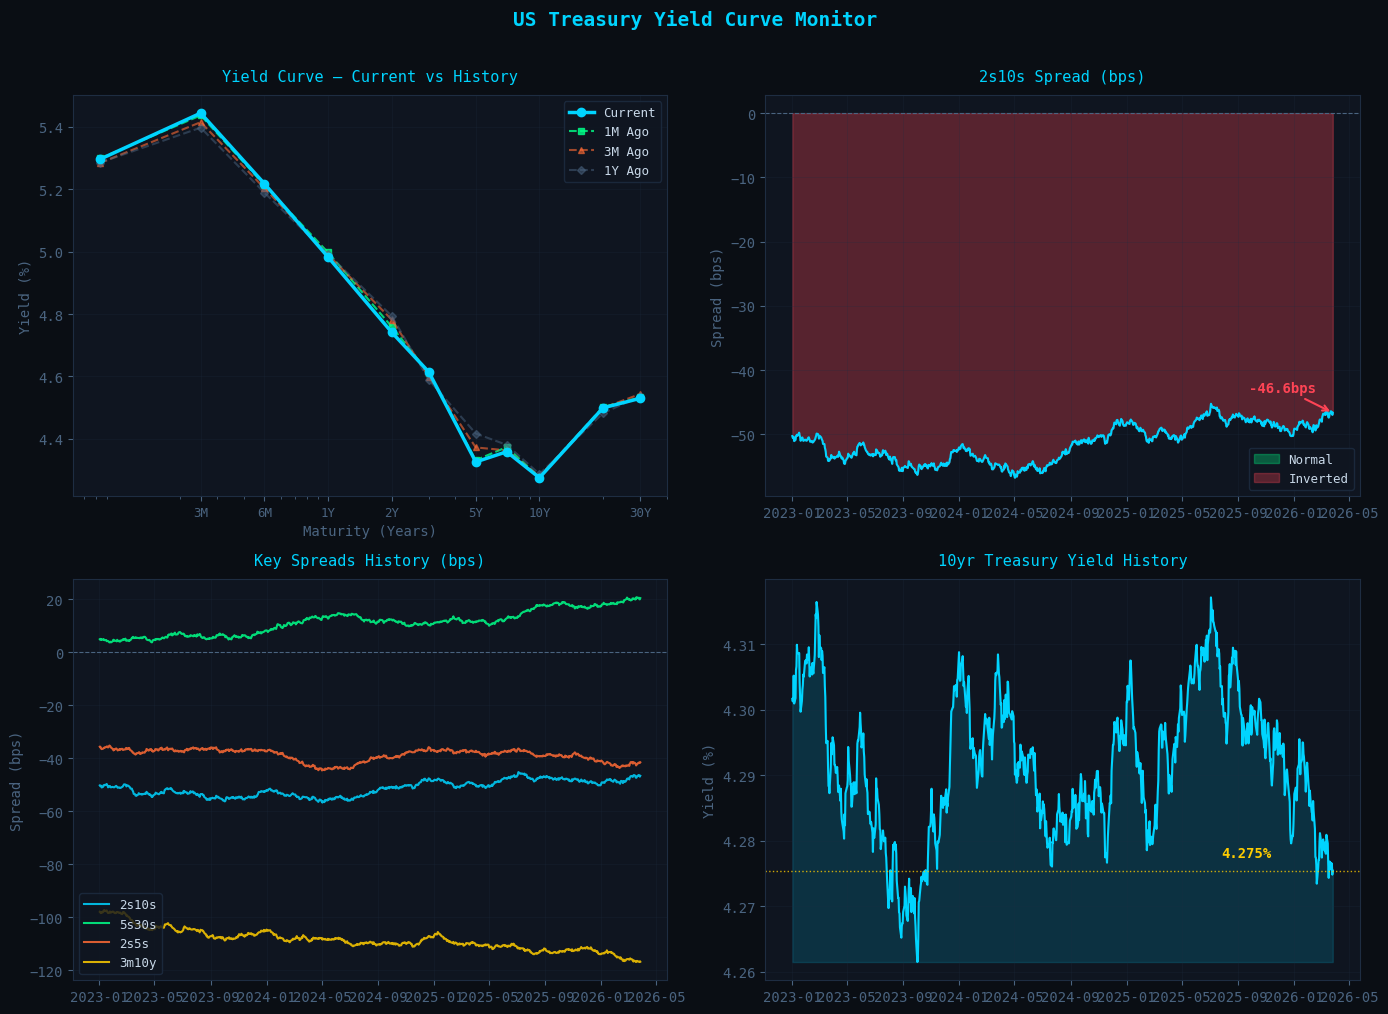

Charts saved to yield_curve_monitor.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('US Treasury Yield Curve Monitor',
             fontsize=14, fontweight='bold', color='#00d4ff', y=1.01)

ACCENT  = '#00d4ff'
ACCENT2 = '#00ff88'
ACCENT3 = '#ff6b35'
WARN    = '#ffcc00'
RED     = '#ff4455'
DIM     = '#4a6480'

mat_values = [MATURITIES[m] for m in common if m in MATURITIES]

# ── Chart 1: Current yield curve vs history
ax1 = axes[0, 0]
ax1.plot(mat_values, [current.get(m)  for m in common], 'o-',
         color=ACCENT,  linewidth=2.5, markersize=6,  label='Current',  zorder=5)
ax1.plot(mat_values, [m1_ago.get(m)   for m in common], 's--',
         color=ACCENT2, linewidth=1.5, markersize=4,  label='1M Ago',   alpha=0.8)
ax1.plot(mat_values, [m3_ago.get(m)   for m in common], '^--',
         color=ACCENT3, linewidth=1.5, markersize=4,  label='3M Ago',   alpha=0.6)
ax1.plot(mat_values, [y1_ago.get(m)   for m in common], 'D--',
         color=DIM,     linewidth=1.5, markersize=4,  label='1Y Ago',   alpha=0.5)
ax1.set_title('Yield Curve — Current vs History', color=ACCENT, fontsize=11, pad=10)
ax1.set_xlabel('Maturity (Years)', color=DIM)
ax1.set_ylabel('Yield (%)', color=DIM)
ax1.legend(fontsize=9, facecolor='#0f1520', edgecolor='#1e2d42')
ax1.grid(alpha=0.3)
ax1.set_xscale('log')
ax1.set_xticks([0.25, 0.5, 1, 2, 5, 10, 30])
ax1.set_xticklabels(['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y'], fontsize=9)

# ── Chart 2: 2s10s spread history
ax2 = axes[0, 1]
if '2s10s' in spreads.columns:
    s = spreads['2s10s'].dropna()
    ax2.fill_between(s.index, s, 0,
                     where=(s >= 0), alpha=0.3, color=ACCENT2, label='Normal')
    ax2.fill_between(s.index, s, 0,
                     where=(s < 0),  alpha=0.3, color=RED,     label='Inverted')
    ax2.plot(s.index, s, color=ACCENT, linewidth=1.5)
    ax2.axhline(0, color=DIM, linewidth=0.8, linestyle='--')
    ax2.set_title('2s10s Spread (bps)', color=ACCENT, fontsize=11, pad=10)
    ax2.set_ylabel('Spread (bps)', color=DIM)
    ax2.legend(fontsize=9, facecolor='#0f1520', edgecolor='#1e2d42')
    ax2.grid(alpha=0.3)
    # Annotate current value
    current_2s10s = s.iloc[-1]
    color_ann = ACCENT2 if current_2s10s >= 0 else RED
    ax2.annotate(f'{current_2s10s:+.1f}bps',
                 xy=(s.index[-1], current_2s10s),
                 xytext=(-60, 15), textcoords='offset points',
                 color=color_ann, fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=color_ann, lw=1.5))

# ── Chart 3: Multiple spreads history
ax3 = axes[1, 0]
spread_colors = [ACCENT, ACCENT2, ACCENT3, WARN]
for (name, col) in zip(['2s10s', '5s30s', '2s5s', '3m10y'], spread_colors):
    if name in spreads.columns:
        ax3.plot(spreads.index, spreads[name].dropna(),
                 linewidth=1.5, color=col, label=name, alpha=0.85)
ax3.axhline(0, color=DIM, linewidth=0.8, linestyle='--')
ax3.set_title('Key Spreads History (bps)', color=ACCENT, fontsize=11, pad=10)
ax3.set_ylabel('Spread (bps)', color=DIM)
ax3.legend(fontsize=9, facecolor='#0f1520', edgecolor='#1e2d42')
ax3.grid(alpha=0.3)

# ── Chart 4: 10yr yield history
ax4 = axes[1, 1]
if '10Y' in raw.columns:
    y10 = raw['10Y'].dropna()
    ax4.fill_between(y10.index, y10, y10.min(),
                     alpha=0.15, color=ACCENT)
    ax4.plot(y10.index, y10, color=ACCENT, linewidth=1.5)
    ax4.set_title('10yr Treasury Yield History', color=ACCENT, fontsize=11, pad=10)
    ax4.set_ylabel('Yield (%)', color=DIM)
    ax4.grid(alpha=0.3)
    # Highlight current level
    ax4.axhline(y10.iloc[-1], color=WARN, linewidth=1,
                linestyle=':', alpha=0.8)
    ax4.annotate(f'{y10.iloc[-1]:.3f}%',
                 xy=(y10.index[-1], y10.iloc[-1]),
                 xytext=(-80, 10), textcoords='offset points',
                 color=WARN, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('yield_curve_monitor.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e14')
plt.show()
print('Charts saved to yield_curve_monitor.png')

---
## 7. Full Dashboard Summary

In [14]:
from datetime import datetime

line = '=' * 65
thin = '-' * 65

print(line)
print('         US TREASURY YIELD CURVE MONITOR')
print(f'         {datetime.now().strftime("%d %B %Y  %H:%M")}')
print(line)

print()
print('CURRENT YIELD CURVE')
print(thin)
mats_short = ['1M','3M','6M','1Y','2Y','5Y','10Y','30Y']
for mat in mats_short:
    if mat in current.index:
        bar = '█' * int(current[mat] * 4)
        print(f'  {mat:>4}: {current[mat]:.3f}%  {bar}')

print()
print('CURVE SHAPE')
print(thin)
print(f'  Classification:    {curve_shape}')
print(f'  Inverted Segments: {len(inversions)}')
if inversions:
    print(f'  Inverted Pairs:    {", ".join(inversions)}')

print()
print('KEY SPREADS')
print(thin)
for name in spreads.columns:
    val  = spreads[name].iloc[-1]
    flag = ' ⚠ INVERTED' if val < 0 and name in ['2s10s','5s30s','3m10y'] else ''
    print(f'  {name:<12}: {val:>+8.1f} bps{flag}')

print()
print('YEAR-OVER-YEAR CHANGES')
print(thin)
for mat in mats_short:
    if mat in current.index and mat in y1_ago.index:
        chg  = (current[mat] - y1_ago[mat]) * 100
        arrow = '↑' if chg > 0 else '↓' if chg < 0 else '→'
        print(f'  {mat:>4}: {current[mat]:.3f}%  ({chg:>+.0f}bps YoY) {arrow}')

print()
print(line)
print('  Data: Federal Reserve Economic Data (FRED)')
print('  Key:  2s10s > 0 = Normal  |  2s10s < 0 = Inverted')
print(line)

         US TREASURY YIELD CURVE MONITOR
         30 March 2026  22:31

CURRENT YIELD CURVE
-----------------------------------------------------------------
    1M: 5.295%  █████████████████████
    3M: 5.443%  █████████████████████
    6M: 5.218%  ████████████████████
    1Y: 4.983%  ███████████████████
    2Y: 4.742%  ██████████████████
    5Y: 4.326%  █████████████████
   10Y: 4.275%  █████████████████
   30Y: 4.530%  ██████████████████

CURVE SHAPE
-----------------------------------------------------------------
  Classification:    INVERTED
  Inverted Segments: 4
  Inverted Pairs:    3m2y, 2s5s, 2s10s, 3m10y

KEY SPREADS
-----------------------------------------------------------------
  2s10s       :    -46.6 bps ⚠ INVERTED
  5s30s       :    +20.4 bps
  2s5s        :    -41.6 bps
  3m10y       :   -116.8 bps ⚠ INVERTED
  butterfly   :    -18.3 bps

YEAR-OVER-YEAR CHANGES
-----------------------------------------------------------------
    1M: 5.295%  (+1bps YoY) ↑
    3M: 5.4

---
## 8. Key Concepts

| Term | Definition | Why It Matters |
|---|---|---|
| **2s10s spread** | 10yr yield minus 2yr yield | Most watched recession indicator |
| **5s30s spread** | 30yr yield minus 5yr yield | Long end slope, inflation expectations |
| **Butterfly** | 5yr minus average of 2yr and 10yr | Curve curvature, relative value signal |
| **Inversion** | Short rates above long rates | Historically precedes recession |
| **Normal curve** | Upward sloping | Healthy economy, growth expected |
| **Flat curve** | Minimal slope | Transition period, uncertainty |
| **Term premium** | Extra yield for holding longer maturities | Embedded in the curve slope |

---

**Built by:** Ryan John  
**Skills demonstrated:** Yield curve analysis, macro awareness, FRED API, Python, pandas, matplotlib  
**Relevant to:** FI Analyst roles 